# **AI Agent_RAG와 연동**

## **1.환경준비**

### (1) 구글 드라이브

#### 1) 구글 드라이브 폴더 생성
* 새 폴더(LangGraph)를 생성하고
* 제공 받은 파일을 업로드

#### 2) 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### (2) 라이브러리

#### 1) 필요한 라이브러리 설치

In [ ]:
!pip install langchain langgraph typing typing_extensions langchain-openai langchain_core langchain-community wikipedia chromadb google-search-results -q

#### 2) 라이브러리 로딩

In [1]:
import pandas as pd
import numpy as np
import os
import openai

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from typing import Annotated, Literal, TypedDict
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, StateGraph, MessagesState
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages
from langchain.chains import RetrievalQA
from langchain_community.vectorstores import Chroma

c:\Users\USER\anaconda3\envs\aivle_pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### (3) OpenAI API Key 확인

In [2]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '../'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'API_KEY.env')

⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

In [3]:
print(os.environ['OPENAI_API_KEY'][:30])

sk-proj-NZCTfKEaIvmWyBt61dmY6A


## 2.RAG1 : 간단한 RAG 구성하기

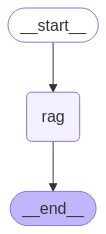

### (1) State 정의

In [4]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

### (2) Vector DB

In [6]:
from langchain.document_loaders import CSVLoader

# CSV 파일 로드
path = './langchain/'
file_name = "sample.csv"
csv_loader = CSVLoader(file_path= path + file_name)
documents_csv = csv_loader.load()

# 벡터 DB 정의
embedding = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = Chroma.from_documents(documents_csv, embedding,
                                    persist_directory= path + "chroma_db")

retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

### (3) Node 정의

* RAG 노드
    * 최근 사용자의 질문을 꺼내서
    * RAG 체인으로 답변을 얻고
    * 새로운 GPT 응답 메시지를 state["messages"]에 추가하는 역할

In [7]:
# RAG Chain
llm = ChatOpenAI(model="gpt-4.1-mini")
rag_chain = RetrievalQA.from_chain_type(llm=llm, retriever=retriever)

# RAG 노드 정의
def rag_node(state: State):
    # 메시지 리스트 중에서 HumanMessage (사용자 질문) 만 골라냄. m.content로 텍스트만 추출. [-1]: 가장 마지막 메시지를 선택
    user_msg = [m.content for m in state["messages"] if isinstance(m, HumanMessage)][-1]
    answer = rag_chain.invoke({"query": user_msg})  # RetrievalQA 함수는 입력으로 {"query": user_msg} 형태를 요구
    return {"messages": [AIMessage(content=answer["result"])]}

### (4) 그래프 정의

In [8]:
# initiate a graph
builder = StateGraph(State)

# add a node
builder.add_node("rag", rag_node)

# connect nodes
builder.add_edge(START, "rag")
builder.add_edge("rag", END)

# compile the graph
graph = builder.compile()

* 그래프 시각화

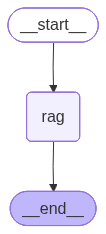

In [10]:
from IPython.display import Image, display

# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

### (5) Graph 실행

In [9]:
result = graph.invoke({"messages": [HumanMessage(content="보안 위협 중 가장 중대한 것이 무엇인가요?")]})

for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

보안 위협 중 가장 중대한 것이 무엇인가요?
================================== Ai Message ==================================

제공된 내용에 따르면 생성형 AI와 대형 언어 모델(LLM)에 대한 보안 위협은 여러 가지가 있지만, 특히 중요한 위협으로는 다음과 같은 점들이 강조되고 있습니다.

1. 시스템 프롬프트 공격: 시스템 프롬프트는 모델의 안전망 역할을 하며 비윤리적이거나 원치 않는 행동을 막는 중요한 요소입니다. 만약 해커가 시스템 프롬프트에 접근해 이를 조작하거나 공격할 방법을 알게 되면, 모델을 효과적으로 통제하거나 악용할 수 있습니다. 따라서 시스템 프롬프트의 보안이 매우 중요합니다.

2. 악성 코드 및 데이터 오염: 해커가 개발팀에 침투하여 소프트웨어에 악성 코드를 삽입하거나, 훈련 데이터·미세 조정·가중치 등을 조작하여 모델을 재학습시키는 공격도 심각한 위협입니다. 이를 통해 해커는 사용자 인프라에 침입하거나, 모델을 가짜 뉴스나 잘못된 정보로 조작할 수 있습니다.

이 두 가지는 AI 모델의 신뢰성과 안전성을 근본적으로 위협할 수 있는 중대한 보안 위험으로 볼 수 있습니다.

따라서 가장 중대한 보안 위협으로는 '시스템 프롬프트에 대한 접근 및 조작'과 '훈련 데이터 및 모델 파라미터의 악의적 오염'을 꼽을 수 있습니다.


## 3.RAG2 : VectorDB를 Tool로 사용

**구축절차**
1. Vector DB 준비 :  
2. Tool 정의 : Vector DB로 부터 검색하는 함수를 툴로 정의
3. LLM+Tool 바인딩
4. 노드 준비 & 분기 함수
5. 그래프 구성

In [11]:
from typing import Literal
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages, MessagesState
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langchain_core.tools import tool
from langchain.tools.render import render_text_description
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langgraph.prebuilt import ToolNode

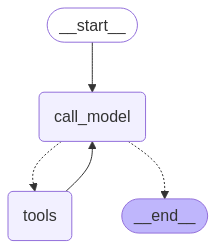

### (1) Vector DB 준비

In [ ]:
from langchain.document_loaders import CSVLoader

# CSV 파일 로드
csv_path = "sample.csv"
csv_loader = CSVLoader(file_path= path + csv_path)
documents_csv = csv_loader.load()

# 벡터 DB 정의
embedding = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = Chroma.from_documents(documents_csv, embedding,
                                    persist_directory= path + "chroma_db01")

retriever = vectorstore.as_retriever(search_kwargs={"k": 3}) # K 보통 3 ~ 5사용

### (2) Tool 정의

In [13]:
@tool
def vectordb_search(query: str) -> str:
    """내장 문서로부터 관련 정보를 검색합니다."""  # docstring 꼭 포함되어야 함!
    # 유사도 기준으로 상위 k개 문서를 벡터스토어에서 검색
    docs = retriever.get_relevant_documents(query)

    # 검색된 문서 내용들을 줄바꿈으로 구분하여 하나의 문자열로 반환
    return "\n\n".join(d.page_content for d in docs)

# tool 리스트
tools = [vectordb_search]

# 툴 실행 노드 (LangGraph 제공)
tool_node = ToolNode(tools)

### (3) LLM+Tool 바인딩

In [14]:
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0).bind_tools(tools)

### (4) 노드 준비 & 분기 함수

In [15]:
# GPT 호출 노드
def call_model(state: State):
    messages = state["messages"]
    response = llm.invoke(messages)
    return {"messages": [response]}

# 툴 사용 여부 판단
def should_continue(state: State) -> Literal["tools", END]:
    last = state["messages"][-1]            # 대화의 가장 마지막 객체(가장 최근 대화)
    if getattr(last, "tool_calls", None):   # last에서 tool_calls 내용이 포함되면, 'tool_calls', 아니면 None
        return "tools"
    return END

### (5) 그래프 구성

In [16]:
builder = StateGraph(State)
builder.add_node("call_model", call_model)
builder.add_node("tools", tool_node)

# connect nodes
builder.add_edge(START, "call_model")
builder.add_conditional_edges("call_model", should_continue)
builder.add_edge("tools", "call_model")

graph = builder.compile()

* 그래프 시각화

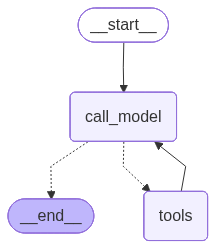

In [17]:
# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

### (6) 실행

In [18]:
result = graph.invoke({"messages": [HumanMessage(content="LangGraph는 무엇인가요?")]})

for message in result["messages"]:
    message.pretty_print()

C:\Users\USER\AppData\Local\Temp\ipykernel_10564\3329454639.py:5: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  docs = retriever.get_relevant_documents(query)


================================ Human Message =================================

LangGraph는 무엇인가요?
================================== Ai Message ==================================
Tool Calls:
  vectordb_search (call_HeMBQWqXftkY5UdPn0OdE4zn)
 Call ID: call_HeMBQWqXftkY5UdPn0OdE4zn
  Args:
    query: LangGraph
================================= Tool Message =================================
Name: vectordb_search

﻿구분: 낯선 라이선스 약관
내용: 현재 오픈소스 AI 라이선스 유형은 다양한 만큼 매우 복잡하다. 오픈소스 AI 모델을 이용하려면 상업적으로 사용해도 괜찮은지, 수정 및 배포가 가능한지, 사내 코드 베이스에 안전하게 통합할 수 있는지 등을 알아봐야 한다. 여기에 몇 가지 새로운 문제가 등장했다. 일단 이전에는 볼 수 없는 제약이 오픈소스 라이선스에 적용됐다.
메타의 라마(Llama) 라이선스를 예로 보자. 라마는 높은 인기를 자랑하는 오픈소스 LLM이다. 메타는 라마에 대해 ‘개방형 접근권을 제공하고 잠재적인 오용 문제를 해결하기 맞춤형 상용 라이선스 모델’을 적용한다고 밝혔다. 또한 이에 대해 ‘책임 및 보호 조치의 균형을 맞추기 위한 조치’라고 소개하고 있다.
이런 라이선스 하에 기업은 상업적으로 라마 모델을 사용할 수 있고 개발자는 기본 라마 모델 위에 추가 작업을 만들어 배포할 수 있다. 단 다른 LLM을 개선하기 위해 라마가 출력하는 결과물을 활용할 수는 없다. (라마 파생 모델은 제외된다.) 또한 기업 또는 그 계열사의 월간 사용자가 700명을 초과하는 경우, 메타에게 라이선스 사용 허락을 요청해야 한다. 메타는 이를

## 4.실습
* 벡터DB와 웹 검색 도구(serpapi)를 포함해서 답하는 Agent 구축하기

In [19]:
from typing import Literal
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages, MessagesState
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.tools import tool
from langchain_community.vectorstores import Chroma
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langgraph.prebuilt import ToolNode
from langchain.agents import load_tools

### (1) Vector DB 준비

In [20]:
from langchain.document_loaders import CSVLoader

# CSV 파일 로드
csv_path = "sample.csv"
csv_loader = CSVLoader(file_path= path + csv_path)
documents_csv = csv_loader.load()

# 벡터 DB 정의
embedding = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = Chroma.from_documents(documents_csv, embedding,
                                    persist_directory= path + "chroma_db01")

retriever = vectorstore.as_retriever(search_kwargs={"k": 3}) # K 보통 3 ~ 5사용

### (2) Tool 정의

In [ ]:
from langchain.tools import Tool

@tool
def vectordb_search(query: str) -> str:
    """OPEN AI 라이선스 내장 문서로부터 관련 정보를 검색합니다."""
    docs = retriever.get_relevant_documents(query)
    return "\n\n".join(d.page_content for d in docs)

llm = ChatOpenAI(model="gpt-4.1-mini")

In [ ]:
# Web Search Tool: SerpAPI
base_tools = load_tools(["serpapi"], llm=llm)

In [ ]:
# 툴 리스트 등록
custom_tool = Tool(
    name="vectordb_search",
    func=vectordb_search,
    description="내장 문서로부터 관련 정보를 검색합니다."
)

tools = base_tools + [custom_tool]

# 툴 로드 


### (3) LLM+Tool 바인딩

In [41]:
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0).bind_tools(tools)

### (4) 노드 준비 & 분기 함수

In [ ]:
# GPT 호출 노드
def call_model(state: State):
    messages = state["messages"]
    response = llm.invoke(messages)
    return {"messages": [response]}

# 툴 실행 노드 (LangGraph 제공)
tool_node = ToolNode(tools)

# 툴 사용 여부 판단
def should_continue(state: State) -> Literal["tools", END]:
    last = state["messages"][-1]            # 대화의 가장 마지막 객체(가장 최근 대화)
    if getattr(last, "tool_calls", None):   # last에서 tool_calls 내용이 포함되면, 'tool_calls', 아니면 None
        return "tools"
    return END

### (5) 그래프 구성

In [43]:
builder = StateGraph(State)
builder.add_node("call_model", call_model)
builder.add_node("tools", tool_node)

# connect nodes
builder.add_edge(START, "call_model")
builder.add_conditional_edges("call_model", should_continue)
builder.add_edge("tools", "call_model")

graph = builder.compile()

* 그래프 시각화

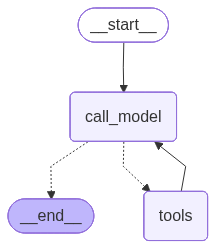

In [44]:
graph

### (6) 실행

In [45]:
result = graph.invoke({"messages": [HumanMessage(content="OPEN AI의 라이선스에 대해 알려줘")]})

for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

OPEN AI의 라이선스에 대해 알려줘
================================== Ai Message ==================================
Tool Calls:
  vectordb_search (call_03oSxqlu44pH8X6b2Zkgzs1O)
 Call ID: call_03oSxqlu44pH8X6b2Zkgzs1O
  Args:
    __arg1: OPEN AI 라이선스
================================= Tool Message =================================
Name: vectordb_search

﻿구분: 낯선 라이선스 약관
내용: 메타와 유사하게 애플은 ‘애플 샘플 코드 라이선스’하에 오픈ELM을 출시했다. 이 라이선스 역시 특허권은 제외하고 저작권 권한만 명시하고 있다. 애플이나 메타 모두 일반적으로 통용되는 오픈소스 라이선스를 사용하지는 않지만, 실제로 코드는 공개되어 있다. 여기에 애플은 실제로 코드뿐만 아니라 모델 가중치, 훈련 데이터 세트, 훈련 로그, 사전 훈련 구성도 공개했다.
이제 오픈소스 라이선스의 또 다른 측면을 살펴보자. 기존의 오픈소스 소프트웨어에서 핵심은 ‘코드’였다. 그리고 그 코드를 통해 소프트웨어가 어떤 기능을 하는지, 잠재적인 문제나 취약점이 있는지 확인할 수 있었다.
하지만 생성형 AI는 단순한 코드가 아니다. 학습 데이터, 모델 가중치, 미세 조정도 마찬가지다. 이러한 모든 요소는 모델의 작동 방식을 이해하고 잠재적인 편향을 파악하는 데 매우 중요다. 예를 들어, 평평한 지구 음모론에 대한 자료를 학습한 모델은 과학 관련 질문에 제대로 답하지 못할 수 있다. 북한 해커가 미세 조정한 모델은 멀웨어를 정확하게 식별하지 못할 수 있다. 그렇다면 오픈소스 LLM은 이러한 모든 정